**1. Import Neccessary Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score


In [2]:
# configuration
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style='darkgrid')

plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

RANDOM_STATE = 42
CSV_PATH = 'housing.csv'
TARGET_COL = 'median_house_value'

**2. Load Data**

In [3]:
df = pd.read_csv(CSV_PATH)

In [4]:
print("DataFrame shape:", df.shape)

DataFrame shape: (20640, 10)


In [5]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,452600.000,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,358500.000,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,352100.000,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,341300.000,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,342200.000,NEAR BAY


**3. Exploratory Data Analysis (EDA)**

In [6]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

**Columns Details:**

1. longitude: A measure of how far west a house is; a higher value is farther west

2. latitude: A measure of how far north a house is; a higher value is farther north

3. housingMedianAge: Median age of a house within a block; a lower number is a newer building

4. totalRooms: Total number of rooms within a block

5. totalBedrooms: Total number of bedrooms within a block

6. population: Total number of people residing within a block

7. households: Total number of households, a group of people residing within a home unit, for a block

8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)

9. medianHouseValue: Median house value for households within a block (measured in US Dollars)

10. oceanProximity: Location of the house w.r.t ocean/sea

In [7]:
# basic data overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Target column:", TARGET_COL)
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Target column: median_house_value
Numerical columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Categorical columns: ['ocean_proximity']


In [9]:
# missing value analysis
print("Missing value per columns:")
print(df.isna().sum())

Missing value per columns:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [10]:
# check presence of encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(20))

longitude
-118.310    162
-118.300    160
-118.290    148
-118.270    144
-118.320    142
-118.280    141
-118.350    140
-118.360    138
-118.190    135
-118.370    128
-118.250    128
-118.200    126
-118.140    125
-118.260    121
-118.130    121
-118.180    120
-118.340    119
-118.210    118
-118.150    116
-118.120    112
Name: count, dtype: int64
latitude
34.060    244
34.050    236
34.080    234
34.070    231
34.040    221
34.090    212
34.020    208
34.100    203
34.030    193
33.930    181
33.940    175
33.970    172
33.990    168
33.880    164
33.980    162
34.110    162
34.160    159
34.120    158
34.150    157
34.010    156
Name: count, dtype: int64
housing_median_age
52.000    1273
36.000     862
35.000     824
16.000     771
17.000     698
34.000     689
26.000     619
33.000     615
18.000     570
25.000     566
32.000     565
37.000     537
15.000     512
19.000     502
27.000     488
24.000     478
30.000     476
28.000     471
20.000     465
29.000     461
Name: coun

NOTE: `total_bedrooms` has missing value

In [ ]:
# duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:", num_duplicates)

Number of duplicate rows: 0


In [12]:
# descriptive stats
df[num_cols].describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000,20640.000,20640.000,20640.000,20433.000,20640.000,20640.000,20640.000,20640.000
mean,-119.570,35.632,28.639,2635.763,537.871,1425.477,499.540,3.871,206855.817
std,2.004,2.136,12.586,2181.615,421.385,1132.462,382.330,1.900,115395.616
min,-124.350,32.540,1.000,2.000,1.000,3.000,1.000,0.500,14999.000
25%,-121.800,33.930,18.000,1447.750,296.000,787.000,280.000,2.563,119600.000
50%,-118.490,34.260,29.000,2127.000,435.000,1166.000,409.000,3.535,179700.000
75%,-118.010,37.710,37.000,3148.000,647.000,1725.000,605.000,4.743,264725.000
max,-114.310,41.950,52.000,39320.000,6445.000,35682.000,6082.000,15.000,500001.000


**4. Data Visualization**

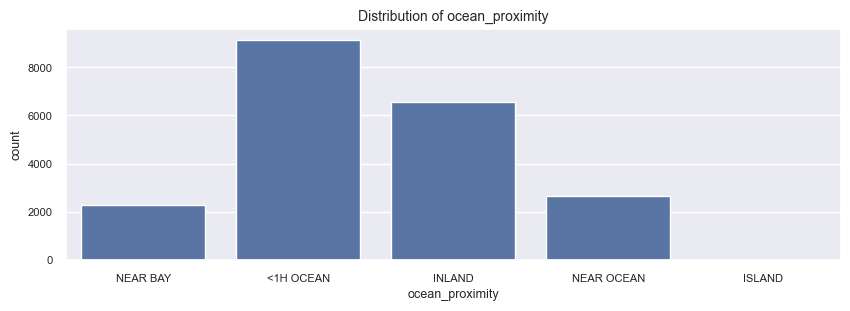

In [13]:
# countplot for categorical columns
for col in cat_cols:
    plt.figure(figsize=(10,3))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

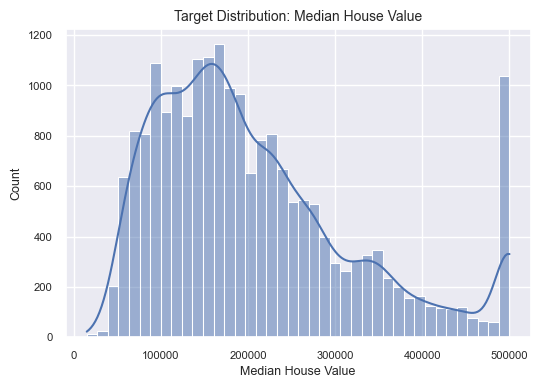

In [14]:
# target column distribution
plt.figure(figsize=(6,4))
sns.histplot(df[TARGET_COL], bins=40, kde=True)
plt.title("Target Distribution: Median House Value")
plt.xlabel("Median House Value")
plt.show()

In [15]:
df[TARGET_COL].value_counts()

median_house_value
500001.000    965
137500.000    122
162500.000    117
112500.000    103
187500.000     93
             ... 
352500.000      1
465000.000      1
457500.000      1
261200.000      1
307900.000      1
Name: count, Length: 3842, dtype: int64

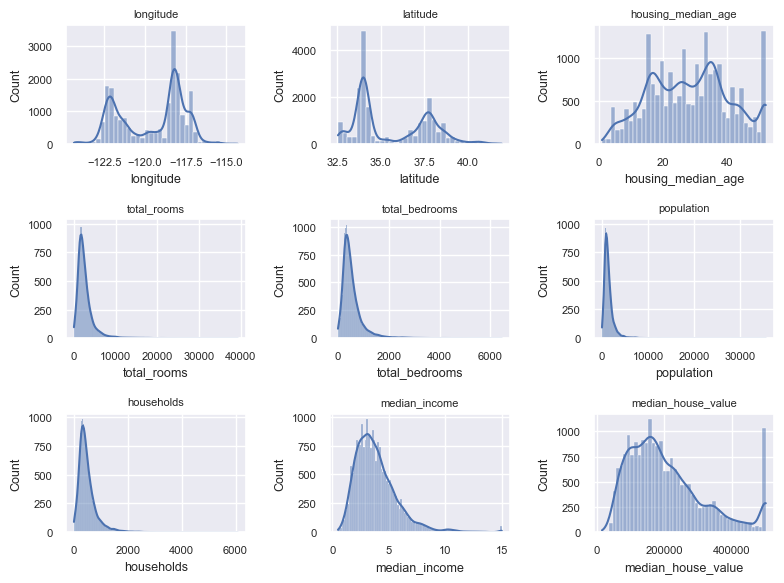

In [16]:
# histogram plot - distribution
fig, axes = plt.subplots(3,3, figsize=(8,6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col],kde=True,ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

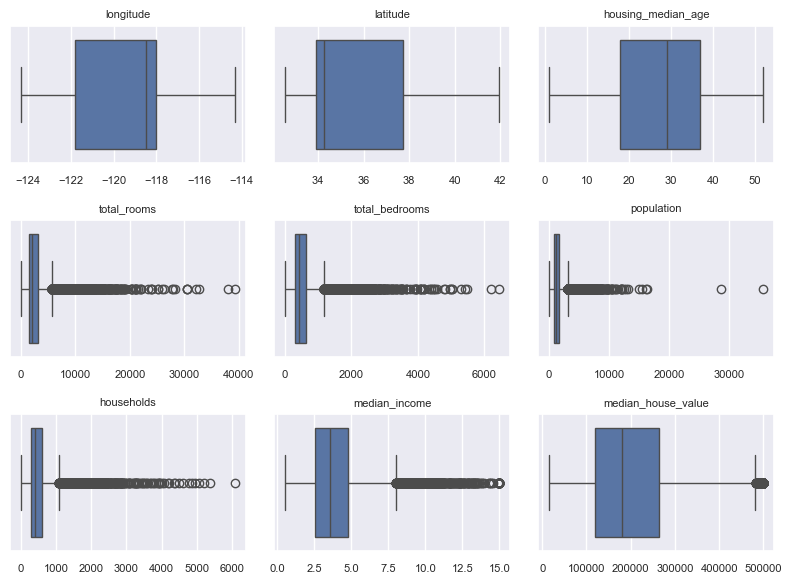

In [17]:
# outliers analysis - boxplot
fig,axes = plt.subplots(3,3, figsize=(8,6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

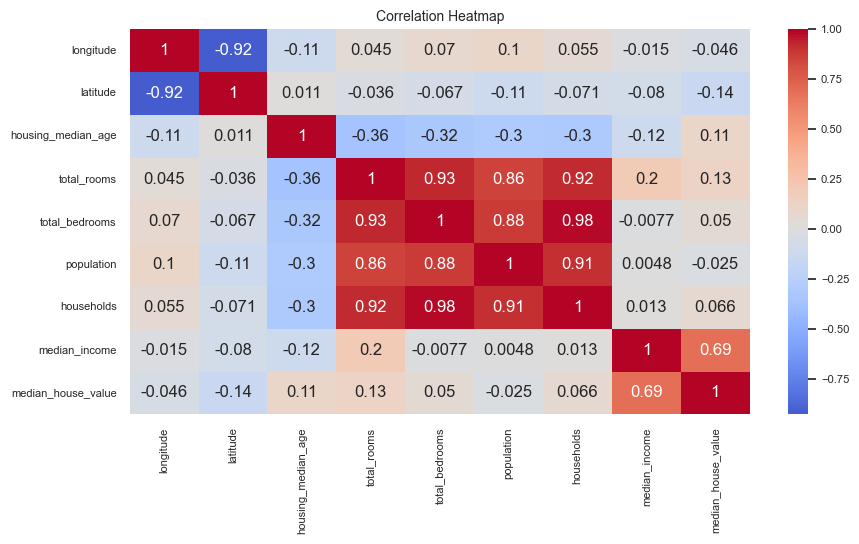

In [18]:
# identify presence of highly correlated columns & feature relationship
plt.figure(figsize=(10,5))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

In [19]:
# correlation with target
corr_with_target= df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print("Correlationw with target:")
print(corr_with_target)

Correlationw with target:
median_house_value    1.000
median_income         0.688
total_rooms           0.134
housing_median_age    0.106
households            0.066
total_bedrooms        0.050
population           -0.025
longitude            -0.046
latitude             -0.144
Name: median_house_value, dtype: float64


Key Insights from EDA

- Dataset has numeric + one categorical feature (ocean_proximity)
- Only total_bedrooms has missing values
- Target (median_house_value) is right-skewed and capped
- Several features show strong skew and outliers
- median_income is the strongest predictor
- High multicollinearity among room and population features

Preprocessing & Evaluation Plan

- Median imputation for missing values
- One-hot encoding for categorical feature
- Feature scaling for linear models
- use pipelines to avoid data leakage
- Baseline model -> CV model selection -> hyperparameter tuning
- Primary metric: RMSE, secondary: MAE and R2
- Final evaluation only on test set

**4. Data Preprocessing**

In [20]:
# separate features and target
X = df.drop(TARGET_COL,axis=1)
y = df[TARGET_COL]

In [21]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.230,37.880,41.000,880.000,129.000,322.000,126.000,8.325,NEAR BAY
1,-122.220,37.860,21.000,7099.000,1106.000,2401.000,1138.000,8.301,NEAR BAY
2,-122.240,37.850,52.000,1467.000,190.000,496.000,177.000,7.257,NEAR BAY
3,-122.250,37.850,52.000,1274.000,235.000,558.000,219.000,5.643,NEAR BAY
4,-122.250,37.850,52.000,1627.000,280.000,565.000,259.000,3.846,NEAR BAY


In [22]:
y.head()

0   452600.000
1   358500.000
2   352100.000
3   341300.000
4   342200.000
Name: median_house_value, dtype: float64

In [23]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=RANDOM_STATE)

In [24]:
print("Train Shape:",X_train.shape)
print("Test Shape:",X_test.shape)

Train Shape: (16512, 9)
Test Shape: (4128, 9)


**Preprocessing Pipeline**

In [25]:
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()
print("Numerical features:",numerical_features)
print("Categorical features:",categorical_features)

# numerical features - preprocessing steps
numerical_transformer = Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy='median')),
        ("scaler",StandardScaler())
    ]
)
# categorical features - preprocessing steps
categorical_transformer = Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy='most_frequent')),
        ("onehot",OneHotEncoder(handle_unknown='ignore'))
    ]
)

# preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num",numerical_transformer,numerical_features),
        ("cat",categorical_transformer,categorical_features)
    ]
)


Numerical features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical features: ['ocean_proximity']


**5. Baseline Model (No CV, No Tuning)**

In [26]:
baseline_pipe = Pipeline(
    [
        ("preprocess",preprocess),
        ('model',LinearRegression())
    ]
)


In [27]:
# preprocess the data and train the baseline model
baseline_pipe.fit(X_train,y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### **Evaluation of baseline model**

In [28]:
train_baseline_pred = baseline_pipe.predict(X_train)
test_baseline_pred = baseline_pipe.predict(X_test)

In [29]:
train_baseline_rmse = root_mean_squared_error(y_train, train_baseline_pred)
train_baseline_mae = mean_absolute_error(y_train, train_baseline_pred)
train_baseline_r2 = r2_score(y_train, train_baseline_pred)

print("=== Train Baseline Metrics (LinearRegression) ===")
print(f"RMSE: {train_baseline_rmse:.3f}")
print(f"MAE: {train_baseline_mae:.3f}")
print(f"R2: {train_baseline_r2:.3f}")

=== Train Baseline Metrics (LinearRegression) ===
RMSE: 68433.937
MAE: 49594.842
R2: 0.650


In [30]:
test_baseline_rmse = root_mean_squared_error(y_test, test_baseline_pred)
test_baseline_mae = mean_absolute_error(y_test, test_baseline_pred)
test_baseline_r2 = r2_score(y_test, test_baseline_pred)

print("=== Test Baseline Metrics (LinearRegression) ===")
print(f"RMSE: {test_baseline_rmse:.3f}")
print(f"MAE: {test_baseline_mae:.3f}")
print(f"R2: {test_baseline_r2:.3f}")

=== Test Baseline Metrics (LinearRegression) ===
RMSE: 70059.193
MAE: 50670.489
R2: 0.625


**6. Model Selection & Optimization**

In [ ]:
# models to try 
models = {
    "LinearRegression":LinearRegression(),
    "Ridge":Ridge(random_state=RANDOM_STATE),
    "Lasso":Lasso(random_state=RANDOM_STATE, max_iter=10000),
    "RandomForest":RandomForestRegressor(),
    "HistGB":HistGradientBoostingRegressor()
}

In [32]:
k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "rmse":"neg_root_mean_squared_error",
    "mae":"neg_mean_absolute_error",
    "r2":"r2"
}

In [33]:
rows = []

for name, model in models.items():
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model",model)
        ]
    )
    score = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    rows.append({
        "model":name,
        "cv_rmse":-score["test_rmse"].mean(),
        "cv_mae":-score["test_mae"].mean(),
        "cv_r2":score["test_r2"].mean()
    })

# sort based on lowest rmse
cv_results = pd.DataFrame(rows).sort_values('cv_rmse')
print("=== CV Model Comparison ===")
cv_results

=== CV Model Comparison ===


,model,cv_rmse,cv_mae,cv_r2
4,HistGB,48270.347,32374.196,0.826
3,RandomForest,49397.991,32278.652,0.817
1,Ridge,68595.617,49664.331,0.648
2,Lasso,68603.233,49667.263,0.648
0,LinearRegression,68604.163,49667.159,0.648


In [34]:
best_row = cv_results.sort_values("cv_rmse").iloc[0]

best_model_name = best_row['model']
best_rmse = best_row['cv_rmse']

print("Best model based on CV RMSE:")
print("Model :",best_model_name)
print("CV RMSE :", best_rmse)

Best model based on CV RMSE:
Model : HistGB
CV RMSE : 48270.347028433505


**BEST MODEL : HistGradientBoostingRegressor**

**7. Hyperparamter Tuning**

In [35]:
hgb_pipe = Pipeline(
    steps = [
        ("preprocess",preprocess),
        ("model",HistGradientBoostingRegressor(random_state=RANDOM_STATE))
    ]
)

In [36]:
# hyperparamter combination
param_grid = {
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [None, 3, 6],
    "model__max_leaf_nodes": [15,31,63],
    "model__min_samples_leaf": [20, 50, 100],
    "model__l2_regularization": [0.0, 0.1, 1.0]
}


In [39]:
grid = GridSearchCV(estimator=hgb_pipe, param_grid=param_grid, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)

In [40]:
# perform grid search
grid.fit(X_train, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__l2_regularization': [0.0, 0.1, ...], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [None, 3, ...], 'model__max_leaf_nodes': [15, 31, ...], ...}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [41]:
print("=== TUNED HistGB CV ===")
print("Best CV RMSE",-grid.best_score_)
print("Best params:", grid.best_params_)

=== TUNED HistGB CV ===
Best CV RMSE 47408.38131673431
Best params: {'model__l2_regularization': 0.1, 'model__learning_rate': 0.1, 'model__max_depth': None, 'model__max_leaf_nodes': 63, 'model__min_samples_leaf': 20}


**8. Retraining with best params**

In [45]:
hgb_best = Pipeline(
    steps = [
        ("preprocess",preprocess),
        ("model",HistGradientBoostingRegressor(
            l2_regularization= 0.1, 
            learning_rate= 0.1, 
            max_depth= None, 
            max_leaf_nodes= 63, 
            min_samples_leaf= 20
        ))
    ]
)

In [46]:
hgb_best.fit(X_train,y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


**9. Final Evaluation**

In [47]:
train_final_pred = hgb_best.predict(X_train)

train_final_rmse = root_mean_squared_error(y_train, train_final_pred)
train_final_mae = mean_absolute_error(y_train, train_final_pred)
train_final_r2 = r2_score(y_train, train_final_pred)

print("=== Final Model (Tuned HGB) Train Performance ===")
print(f"RMSE : {train_final_rmse:.3f}")
print(f"MAE : {train_final_mae:.3f}")
print(f"R2 : {train_final_r2:.3f}")

=== Final Model (Tuned HGB) Train Performance ===
RMSE : 35934.025
MAE : 24506.465
R2 : 0.903


In [48]:
test_final_pred = hgb_best.predict(X_test)

test_final_rmse = root_mean_squared_error(y_test, test_final_pred)
test_final_mae = mean_absolute_error(y_test, test_final_pred)
test_final_r2 = r2_score(y_test, test_final_pred)

print("=== Final Model (Tuned HGB) Test Performance ===")
print(f"RMSE : {test_final_rmse:.3f}")
print(f"MAE : {test_final_mae:.3f}")
print(f"R2 : {test_final_r2:.3f}")

=== Final Model (Tuned HGB) Test Performance ===
RMSE : 46616.817
MAE : 30810.451
R2 : 0.834


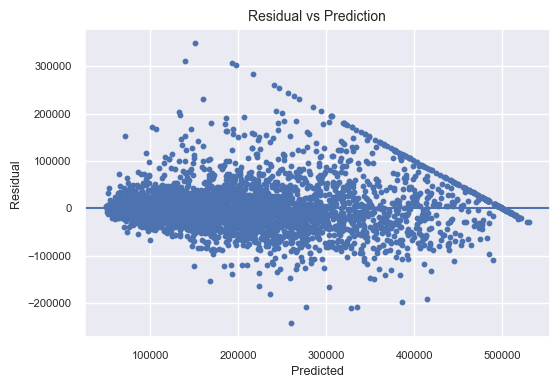

In [50]:
# residual
residual = y_test - test_final_pred

plt.figure(figsize=(6,4))
plt.scatter(test_final_pred, residual, s=10)
plt.axhline(0)
plt.title("Residual vs Prediction")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.show()

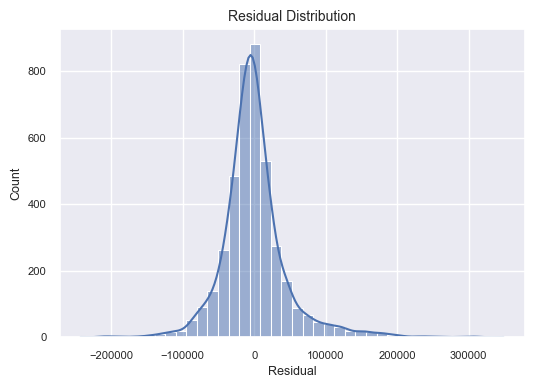

In [51]:
plt.figure(figsize=(6,4))
sns.histplot(residual, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

In [52]:
import joblib

joblib.dump(hgb_best,"model.joblib")

['model.joblib']